In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

In [44]:
VARIABLE = "heat_index" # temp or heat_index or edv

START_DATE = date(2018, 1, 1)
REGION = 5

INPUT_FILE = f"../data/{VARIABLE}/{VARIABLE}_stl.csv"
OUTPUT_FILE = f"../plots/stl/{VARIABLE}_stl.png"

df = pd.read_csv(INPUT_FILE, index_col = 0)
df

,seasonal,trend,remainder
1,-14.534376,15.707211,-13.731437
2,-15.646740,15.705693,-11.046990
3,-16.043410,15.704174,-8.801908
4,-16.541739,15.702655,-9.615409
5,-15.380357,15.701137,-11.878615
...,...,...,...
1822,-10.087741,15.345299,-6.569080
1823,-11.238335,15.345832,0.066087
1824,-11.155770,15.346366,5.345868
1825,-10.749739,15.346900,4.229655


In [45]:
END_DATE = START_DATE + timedelta(days = len(df)-1)
x_tick_ts = []
x_tick_years = []
for year in range(START_DATE.year, END_DATE.year+2):
    days_since = (date(year, 1, 1) - START_DATE).days + 1
    x_tick_ts.append(days_since)
    x_tick_years.append(year)

if VARIABLE == "edv":
    suptitle = "EDV"
elif VARIABLE == "temp":
    suptitle = "Temperature"
elif VARIABLE == "heat_index":
    suptitle = "Heat Index"

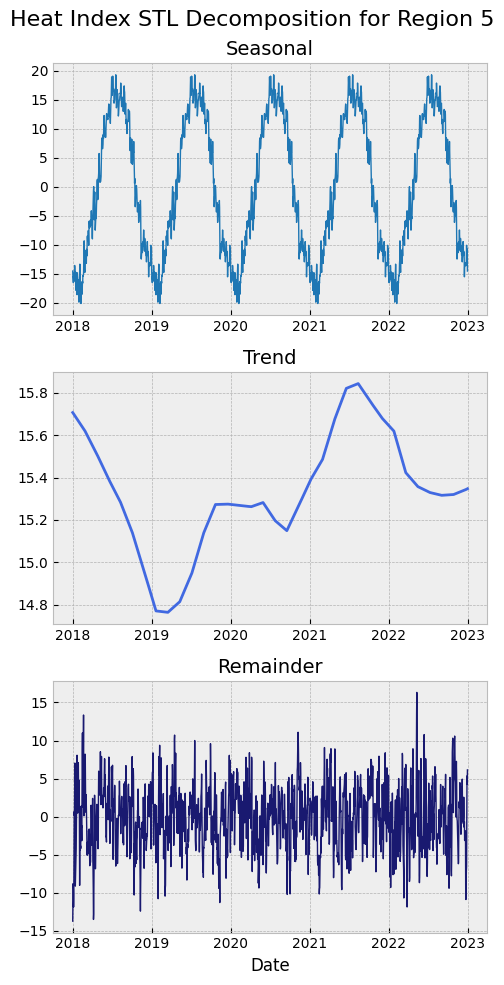

In [46]:
plt.style.use('bmh')
fig, axs = plt.subplots(3, 1, figsize = (5, 10))
colors = ["tab:blue", "royalblue", "midnightblue"]
for i, col in enumerate(df.columns):
    ax = axs[i]
    ax.plot(df[col], lw = 2 if i == 1 else 1, c = colors[i])
    ax.set_title(col.capitalize(), fontsize = 14)
    ax.set_xticks(x_tick_ts, x_tick_years)

axs[2].set_xlabel("Date")

plt.suptitle(f"{suptitle} STL Decomposition for Region {REGION}", fontsize = 16)
plt.tight_layout()

fig.savefig(OUTPUT_FILE, dpi = 300)